# RQ1 — Vulnerability Detection Conformity Results
Loads all per-seed metrics CSVs from `../results_todos/rq1/`, then visualizes accuracy, revision, and confidence metrics across models and conditions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("../results_todos/rq1")

RQ1_CONDITIONS = [
    "all_correct_absent", "all_correct_present",
    "mixed_absent",       "mixed_present",
    "all_wrong_absent",   "all_wrong_present",
    "ALL",
]
CONDITION_ORDER = [c for c in RQ1_CONDITIONS if c != "ALL"]
CONDITION_LABELS = {
    "all_correct_absent":  "All-correct\n(no auth)",
    "all_correct_present": "All-correct\n(auth)",
    "mixed_absent":        "Mixed\n(no auth)",
    "mixed_present":       "Mixed\n(auth)",
    "all_wrong_absent":    "All-wrong\n(no auth)",
    "all_wrong_present":   "All-wrong\n(auth)",
}

per_seed_dfs = []
for csv_path in sorted(RESULTS_DIR.rglob("*.metrics.csv")):
    if "primevul_dataset" in csv_path.name or "_all_seeds" in csv_path.name:
        continue
    parts = csv_path.parts
    if not any(p.startswith("seed_") for p in parts):
        continue
    df = pd.read_csv(csv_path)
    df = df[df["condition"].isin(RQ1_CONDITIONS)]
    if not df.empty:
        per_seed_dfs.append(df)

all_per_seed = pd.concat(per_seed_dfs, ignore_index=True) if per_seed_dfs else pd.DataFrame()
combined = all_per_seed.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

MODELS = sorted(combined["model"].unique())
PALETTE = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, PALETTE))

print(f"Models: {MODELS}")
print(f"Conditions: {sorted(combined['condition'].unique())}")


Models: ['llama31_it', 'mistral_it', 'phi35_it', 'qwen25_it']
Conditions: ['ALL', 'all_correct_absent', 'all_correct_present', 'all_wrong_absent', 'all_wrong_present', 'mixed_absent', 'mixed_present']


## Per-model metrics tables

In [2]:
display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

for model in MODELS:
    df_model = combined[combined["model"] == model].copy()
    df_model = df_model[df_model["condition"].isin(CONDITION_ORDER)]
    present = [c for c in CONDITION_ORDER if c in df_model["condition"].values]
    df_model["condition"] = pd.Categorical(df_model["condition"], categories=present, ordered=True)
    df_model = df_model.sort_values("condition")[display_cols].reset_index(drop=True)
    print(f"\n{'─'*60}\n  {model.upper()}\n{'─'*60}")
    display(df_model.style
        .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                 **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
        .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
        .background_gradient(subset=["harm_pct"],  cmap="Reds",   vmin=0,   vmax=100)
        .background_gradient(subset=["ben_pct"],   cmap="Greens", vmin=0,   vmax=100)
        .set_caption(model)
    )



────────────────────────────────────────────────────────────
  LLAMA31_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,53.1,56.3,3.2,35.0,29.9,40.7,-0.8
1,all_correct_present,500,53.1,57.9,4.8,36.5,29.9,44.0,-0.6
2,mixed_absent,500,53.1,48.4,-4.7,29.8,32.5,26.8,-0.6
3,mixed_present,500,53.1,48.9,-4.1,32.4,34.4,30.1,-0.6
4,all_wrong_absent,500,53.1,45.2,-7.8,30.0,35.7,23.6,-1.4
5,all_wrong_present,500,53.1,42.8,-10.3,32.5,40.3,23.6,-1.2



────────────────────────────────────────────────────────────
  MISTRAL_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,499.83,54.8,57.3,2.5,23.1,18.7,28.3,-0.7
1,all_correct_present,498.67,54.6,59.3,4.6,27.2,20.6,35.2,-0.8
2,mixed_absent,498.67,54.8,54.7,-0.1,1.9,1.8,2.0,-0.0
3,mixed_present,497.67,54.8,54.1,-0.7,5.5,5.7,5.3,0.1
4,all_wrong_absent,497.33,54.9,43.1,-11.8,29.6,37.7,19.8,-0.5
5,all_wrong_present,499,54.9,43.1,-11.8,32.3,40.0,22.7,-0.6



────────────────────────────────────────────────────────────
  PHI35_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,50.2,65.9,15.6,15.6,0.0,31.4,0.0
1,all_correct_present,500,50.2,81.3,31.1,31.1,0.0,62.4,0.0
2,mixed_absent,500,50.2,50.1,-0.1,1.9,2.0,1.7,0.0
3,mixed_present,500,50.2,51.8,1.5,7.1,5.6,8.6,0.0
4,all_wrong_absent,500,50.2,31.8,-18.4,18.4,36.7,0.0,0.0
5,all_wrong_present,500,50.2,19.3,-31.0,31.0,61.6,0.0,0.0



────────────────────────────────────────────────────────────
  QWEN25_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,all_correct_absent,500,57.5,92.0,34.5,47.1,11.0,95.9,0.8
1,all_correct_present,500,57.5,96.2,38.6,45.1,5.6,98.5,0.9
2,mixed_absent,500,57.5,50.9,-6.7,38.5,39.3,37.5,0.8
3,mixed_present,500,57.5,48.5,-9.0,38.3,41.1,34.5,0.8
4,all_wrong_absent,500,57.5,7.4,-50.1,59.8,95.6,11.5,0.8
5,all_wrong_present,500,57.5,5.2,-52.3,58.9,96.7,7.9,0.9


## Round-1 vs Round-2 accuracy by condition

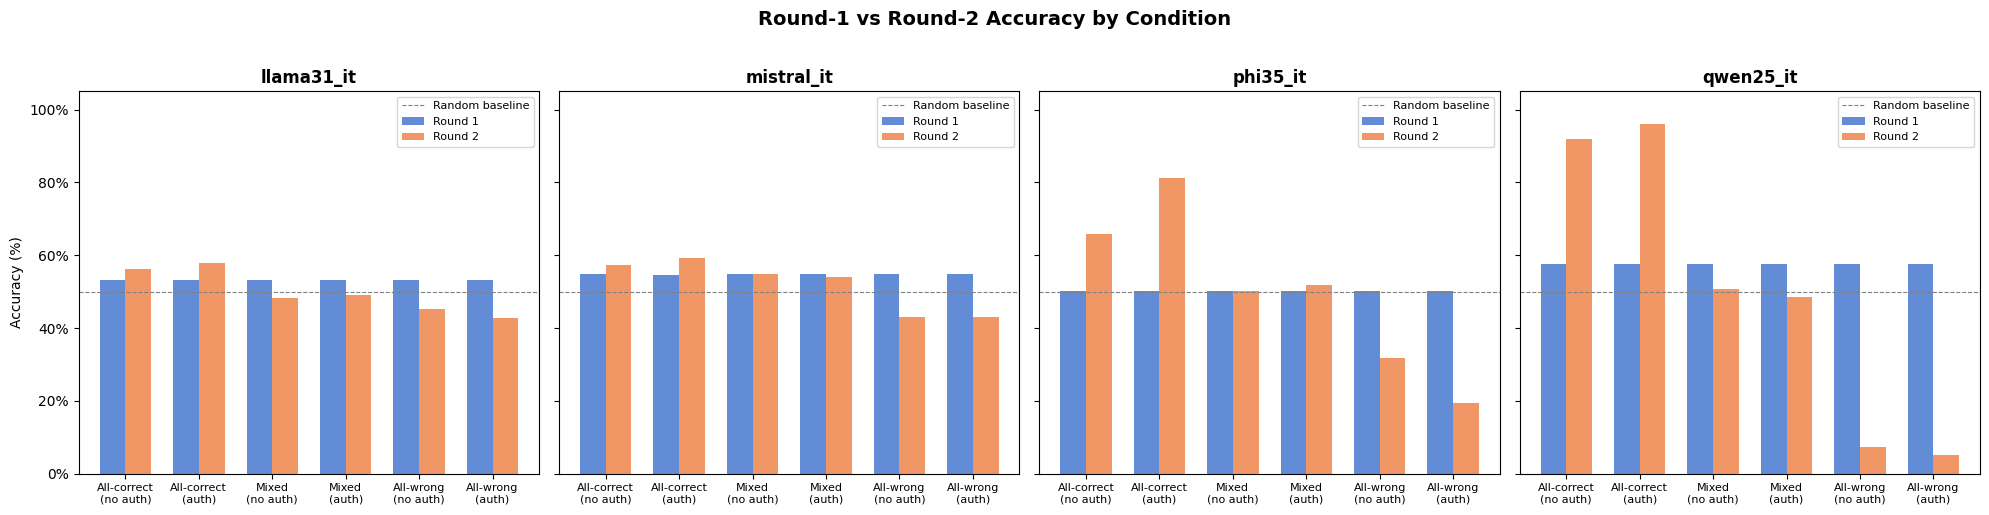

In [3]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(CONDITION_ORDER))].copy()
    present = [c for c in CONDITION_ORDER if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")
    x = range(len(df_m))
    width = 0.35
    ax.bar([i - width/2 for i in x], df_m["acc_r1"], width, label="Round 1", color="#4878d0", alpha=0.85)
    ax.bar([i + width/2 for i in x], df_m["acc_r2"], width, label="Round 2", color="#ee854a", alpha=0.85)
    ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Random baseline")
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xticks(list(x))
    ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in df_m["condition"]], fontsize=8)
    ax.set_ylabel("Accuracy (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)

plt.suptitle("Round-1 vs Round-2 Accuracy by Condition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_r1_r2_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()


## Δ Accuracy heatmap — models × conditions

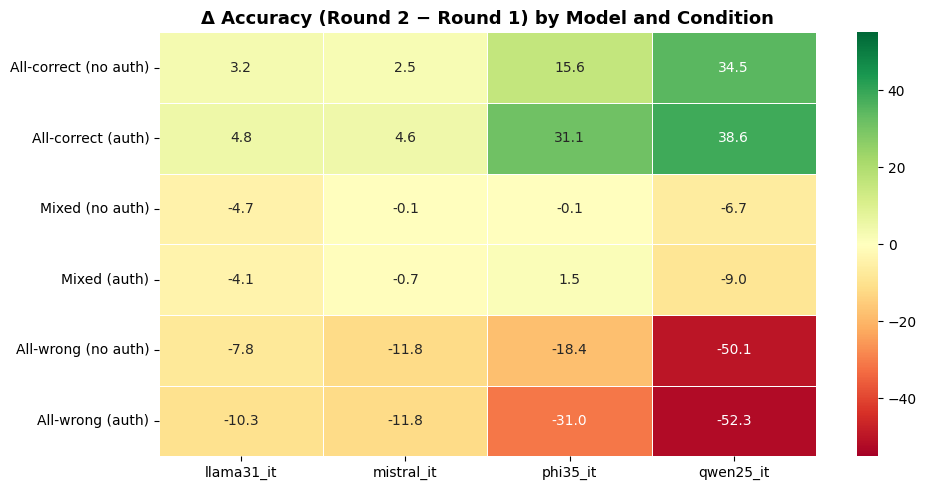

In [6]:
df_plot = combined[combined["condition"].isin(CONDITION_ORDER)]
pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
pivot = pivot.reindex([c for c in CONDITION_ORDER if c in pivot.index])

fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(MODELS)), 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("\u0394 Accuracy (Round 2 \u2212 Round 1) by Model and Condition", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "delta_acc_heatmap.png", dpi=150, bbox_inches="tight")
plt.savefig(RESULTS_DIR / "conformity_consensus_heatmap.pdf", bbox_inches="tight")
plt.show()


## Harmful vs Beneficial revision rate

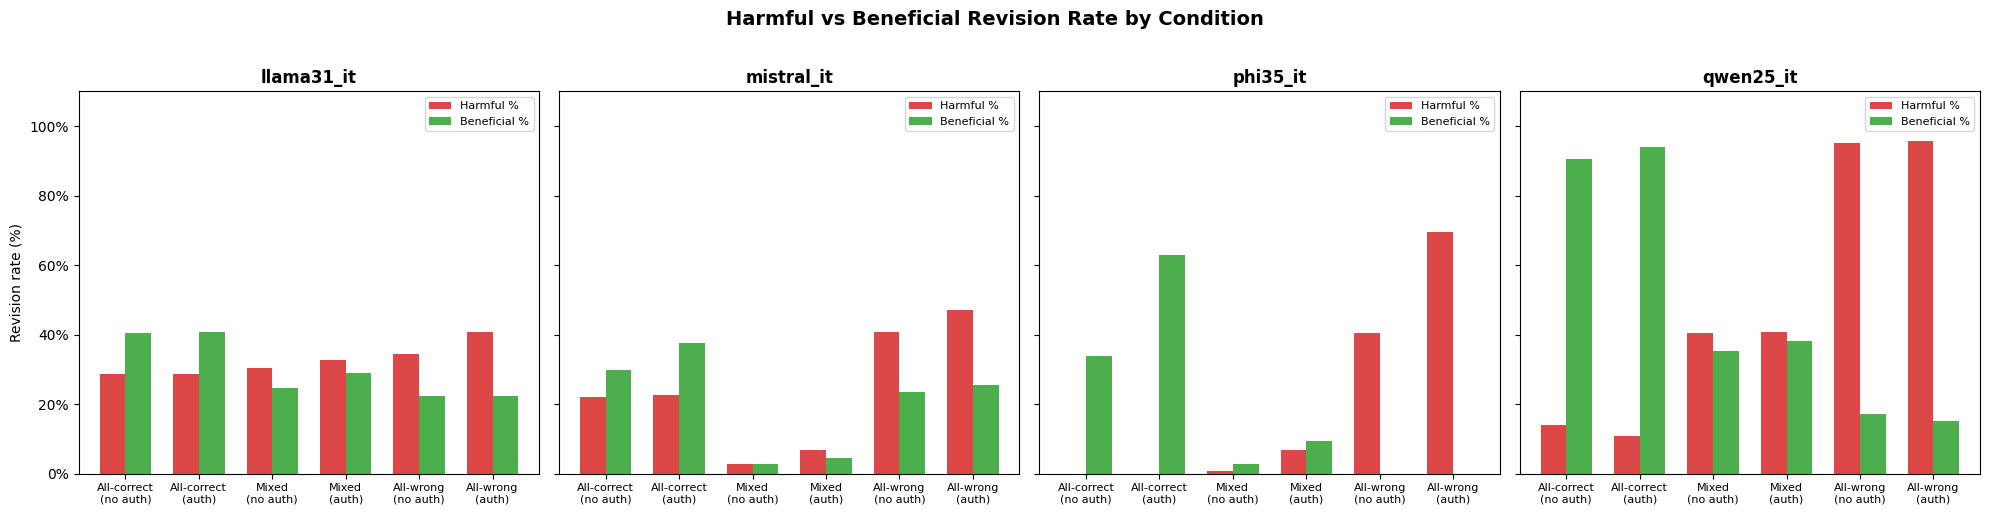

In [ ]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(CONDITION_ORDER))].copy()
    present = [c for c in CONDITION_ORDER if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")
    x = range(len(df_m))
    width = 0.35
    ax.bar([i - width/2 for i in x], df_m["harm_pct"], width, label="Harmful %", color="#d62728", alpha=0.85)
    ax.bar([i + width/2 for i in x], df_m["ben_pct"],  width, label="Beneficial %", color="#2ca02c", alpha=0.85)
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xticks(list(x))
    ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in df_m["condition"]], fontsize=8)
    ax.set_ylabel("Revision rate (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)

plt.suptitle("Harmful vs Beneficial Revision Rate by Condition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "harmful_vs_beneficial.png", dpi=150, bbox_inches="tight")
plt.show()


## Cross-model accuracy drop under all-wrong consensus

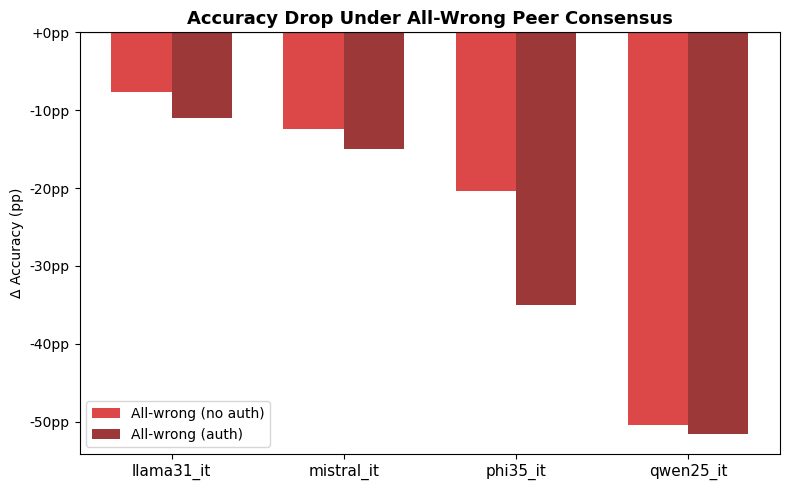

In [ ]:
all_wrong = combined[combined["condition"].isin(["all_wrong_absent", "all_wrong_present"])].copy()

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(MODELS))
for i, cond in enumerate(["all_wrong_absent", "all_wrong_present"]):
    df_c = all_wrong[all_wrong["condition"] == cond].set_index("model")
    offsets = [j + i * 0.35 - 0.175 for j in x]
    vals = [df_c.loc[m, "delta_acc"] if m in df_c.index else 0 for m in MODELS]
    label = "All-wrong (no auth)" if "absent" in cond else "All-wrong (auth)"
    color = "#d62728" if "absent" in cond else "#8c1515"
    ax.bar(offsets, vals, 0.35, label=label, color=color, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(MODELS, fontsize=11)
ax.set_ylabel("\u0394 Accuracy (pp)")
ax.set_title("Accuracy Drop Under All-Wrong Peer Consensus", fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "allwrong_accuracy_drop.png", dpi=150, bbox_inches="tight")
plt.show()


## Mean confidence change heatmap

> **Note:** Phi-3.5-mini outputs a constant confidence of 7 regardless of condition — its `mean_dC` values are unreliable and are excluded from this heatmap.

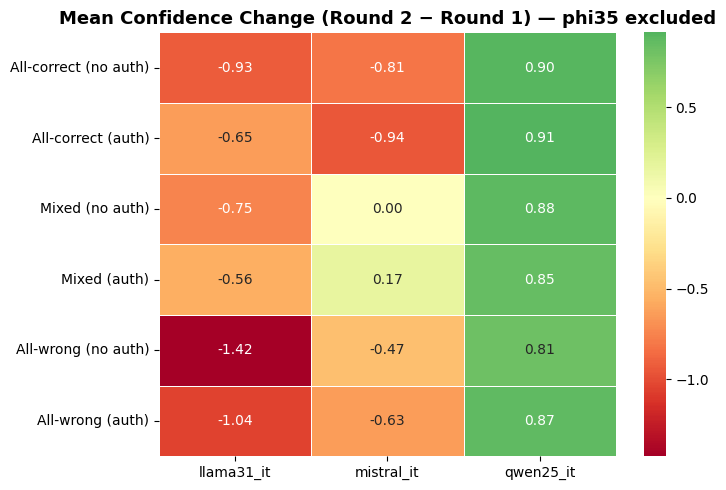

In [ ]:
# FIX: exclude Phi35 from confidence heatmap — its confidence scores are unreliable (always 7)
CONFIDENCE_MODELS = [m for m in MODELS if m != "phi35_it"]

df_plot = combined[(combined["condition"].isin(CONDITION_ORDER)) & (combined["model"].isin(CONFIDENCE_MODELS))]
pivot_dc = df_plot.pivot_table(index="condition", columns="model", values="mean_dC")
pivot_dc = pivot_dc.reindex([c for c in CONDITION_ORDER if c in pivot_dc.index])

fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(CONFIDENCE_MODELS)), 5))
sns.heatmap(pivot_dc, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Mean Confidence Change (Round 2 \u2212 Round 1) — phi35 excluded", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot_dc.index], rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confidence_change_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
